# EEG Frequency Band Analysis and Classification

## Goal
In this notebook I want to explores EEG signals and gain familiarity with the subject. I will be looking at eeg data for the first time and try to identify problems, aswell as handel them, in my attempt to classify
between the two mental states of open or closed eyes.

For this task I will be looking at frequency bandpowers and findout, whether my current understanding of the brain is reflected in the data at hand.

The focus will be on letting my curriosity lead me through the different signal processing steps and interpreting the results according to my current knowledge.

## About the dataset

All data is from one continuous 117 second long EEG measurement with the Emotiv EEG Neuroheadset. The eye state was detected via a camera during the EEG measurement and added later manually to the file after analysing the video frames. This way transitions between states happen naturally. The lable '1' indicates the eye-closed state and the lable '0' indicates the eye-open state. All values are in chronological order with the first measured value at the top of the data.

In [635]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.io import arff
import plotly.express as px

from itertools import cycle
from scipy import stats

## Load Data & get familiar

The data consists of 14980 samples and 14 channels + the lable. The dataset is small, it has no missing values and the labels are slightly imbalanced, but not concerning.

In [636]:
# Load EEG data from ARFF file
df, meta = arff.loadarff('EEG Eye State.arff')
df = pd.DataFrame(df)
df['eyeDetection'] = df['eyeDetection'].astype(int)
print("Shape of data:", df.shape, "\n")
    
print(f"First rows:")
display(df.head(3))

print(f"\nLast rows:")
display(df.tail(3))

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values per column:")
display(df.info())

print("\nColumn names:", df.columns.tolist())

print("Classdistribution:")
display(df['eyeDetection'].value_counts())
print("In percentage:")
display(df['eyeDetection'].value_counts(normalize=True))

Shape of data: (14980, 15) 

First rows:


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0



Last rows:


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49,1
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77,1
14979,4287.69,3997.44,4260.00,4121.03,4333.33,4616.41,4088.72,4638.46,4212.31,4226.67,4167.69,4274.36,4597.95,4350.77,1



Summary statistics:


...

None


Column names: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection']
Classdistribution:


eyeDetection
0    8257
1    6723
Name: count, dtype: int64

In percentage:


eyeDetection
0    0.551202
1    0.448798
Name: proportion, dtype: float64

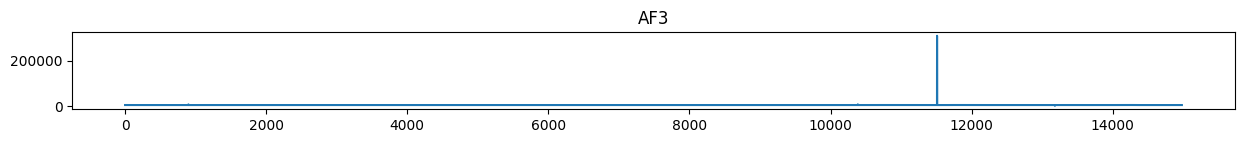

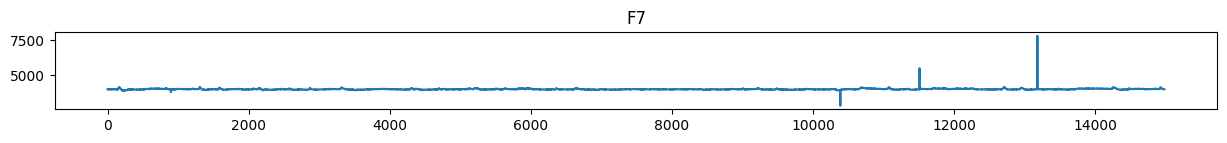

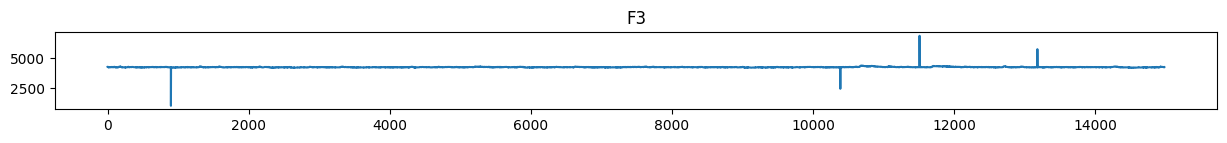

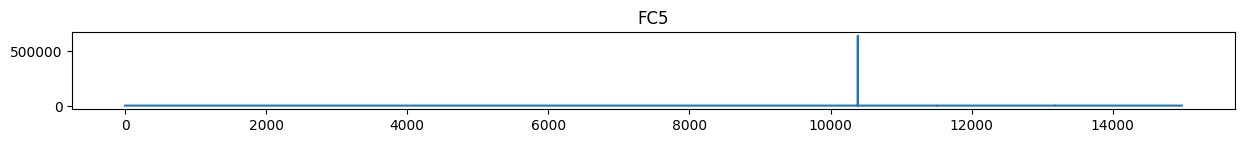

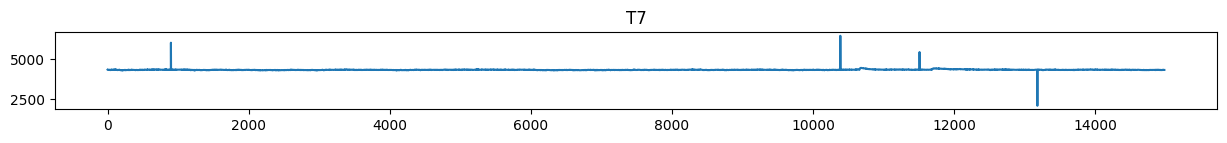

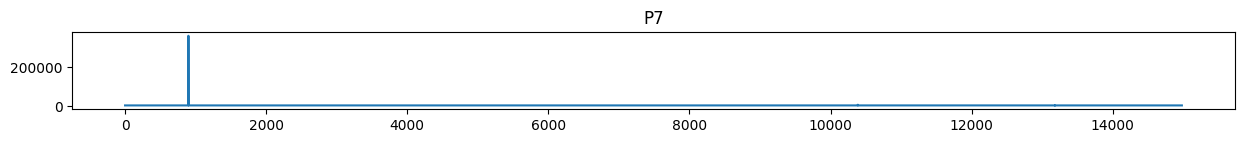

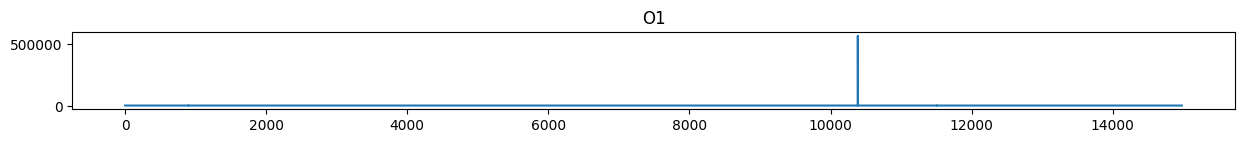

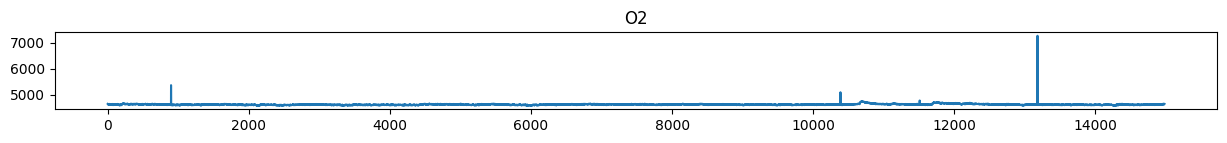

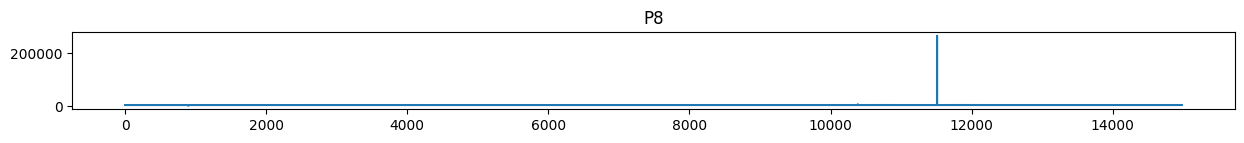

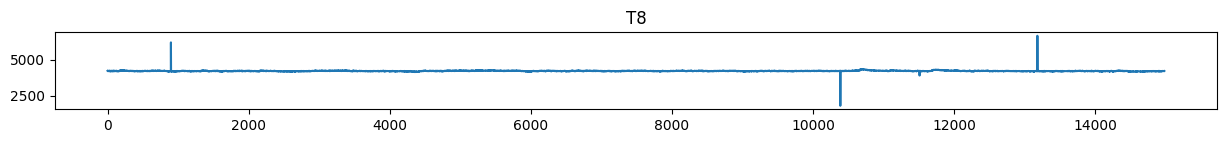

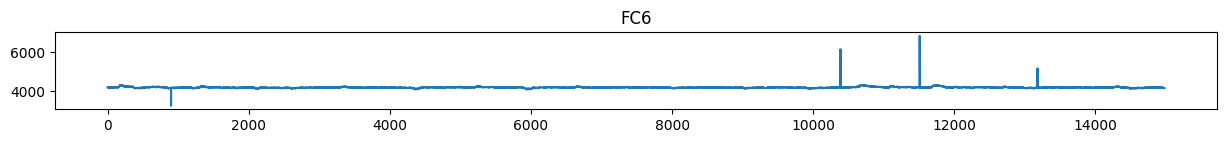

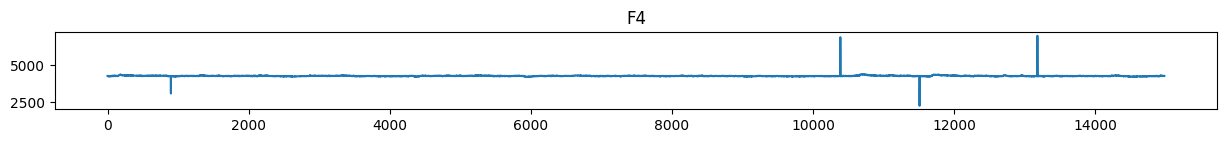

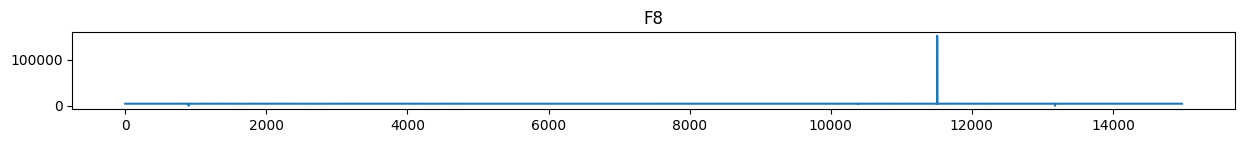

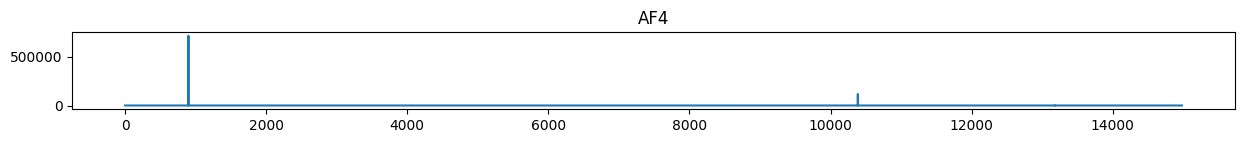

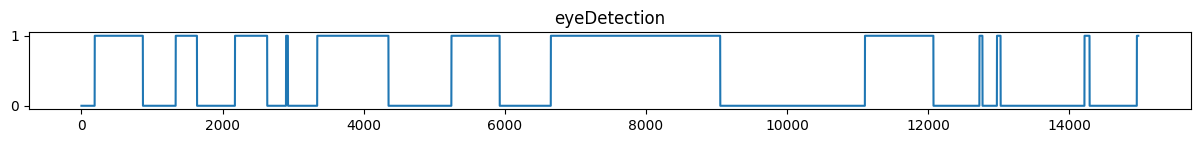

In [637]:
# Plotting each channel
for f in df.columns:
    df[f].plot(figsize=(15, 1), title=f)
    plt.show()

## Outlier detection and removal
The data looks almost flat with only a few huge spikes, which distorte the whole scaling. We treat them as outliers, since brain signal wouldnt produce such big spikes.

We calculate the mean and the std over a sliding window and calculate the z score from that. Every value deveating more than the threshold gets removed and interpolated.

This step can be done twice, removing more subtile outliers in the second run

In [638]:
def remove_outliers_rolling_zscore(df, window=50, threshold=5):
    """
    Removes outliers using rolling z-score and interpolates missing values.

    Parameters:
        df (pd.DataFrame): Input data
        window (int): Rolling window size
        threshold (float): Z-score threshold for outlier detection

    Returns:
        df_clean (pd.DataFrame): Cleaned DataFrame
    """

    # --- Rolling statistics ---
    rolling_mean = df.rolling(window=window, center=True).mean()
    rolling_std = df.rolling(window=window, center=True).std()

    # --- Z-score ---
    z = (df - rolling_mean) / (rolling_std + 1e-10)

    # --- Mask outliers ---
    mask = np.abs(z) > threshold

    df_clean = df.copy()
    df_clean[mask] = np.nan

    # --- Interpolate missing values ---
    df_clean = df_clean.interpolate(axis=0).bfill().ffill()

    return df_clean

df_first_clean = remove_outliers_rolling_zscore(df, window=50, threshold=5)
df_clean = remove_outliers_rolling_zscore(df_first_clean, window=50, threshold=5)
print(df_clean.shape)

(14980, 15)


The DC part is represented by the mean of the samples. We remove it since we are not interested in the absolut values.

We can also subtract the mean of the channels, thereby reducing noice potentially.

In [639]:
# Remove DC offset
X = df_clean.iloc[:, :-1]
X = X - X.mean()
df_clean = X.copy()

X_car = X.sub(X.mean(axis=1), axis=0)
print(X_car.shape)

df_clean = X_car.copy()

# Scale labels to [-1, 1]
df_clean["eyeDetection"] = (df["eyeDetection"] -0.5)*2
print(df_clean.shape)

(14980, 14)
(14980, 15)


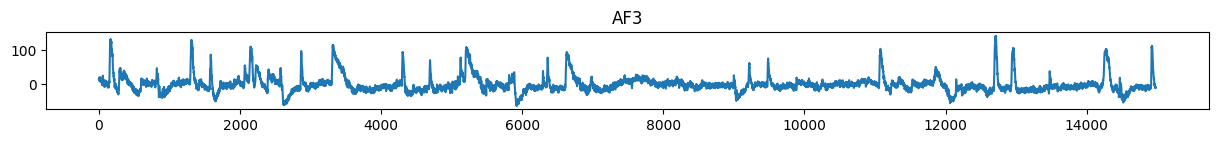

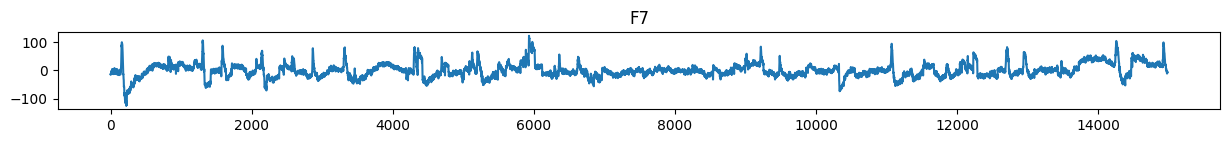

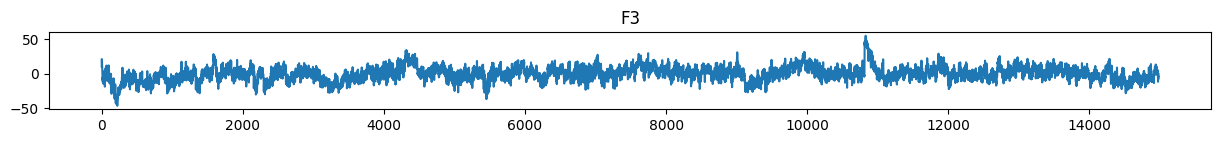

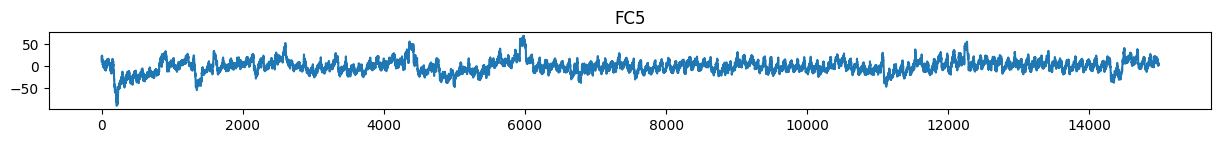

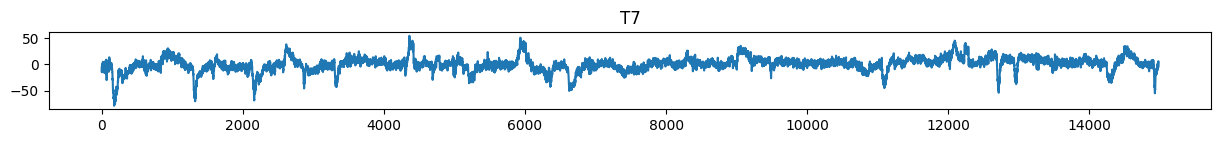

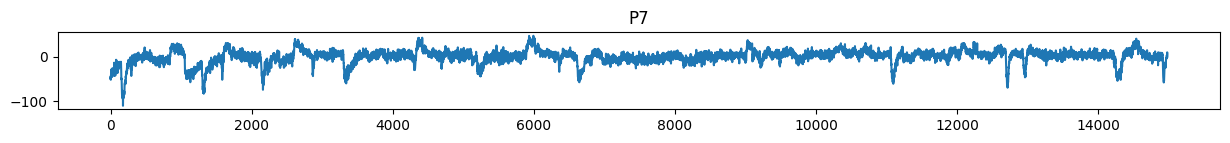

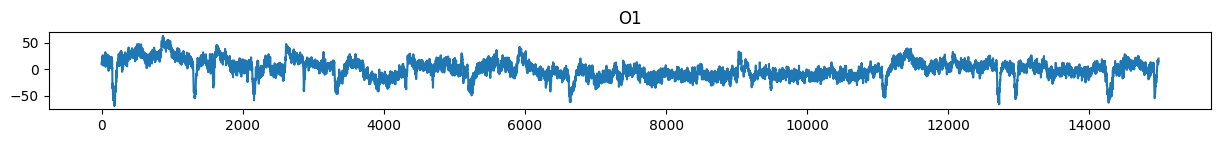

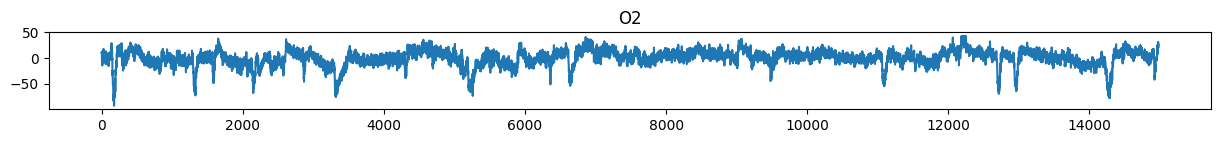

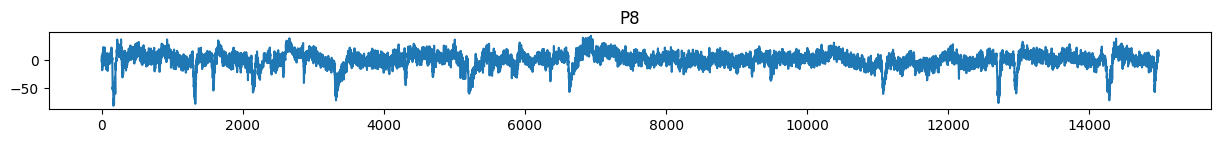

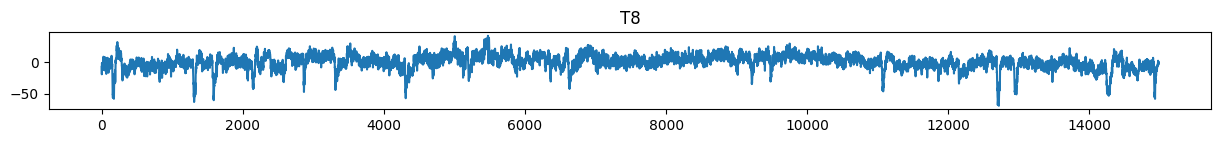

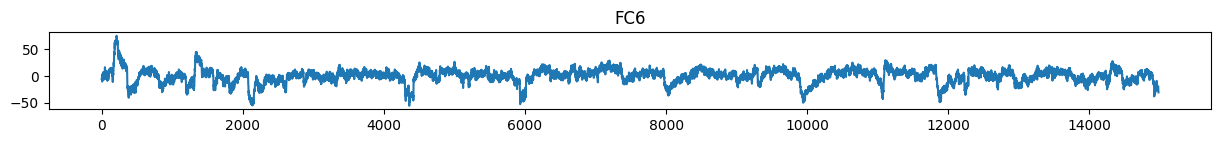

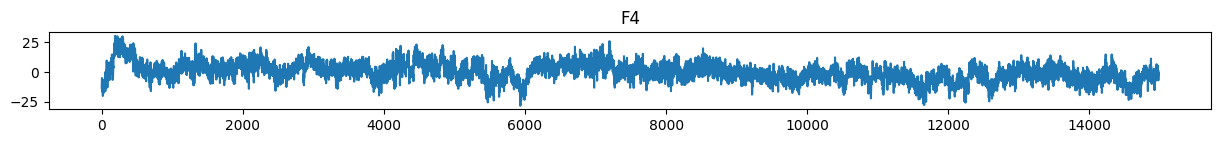

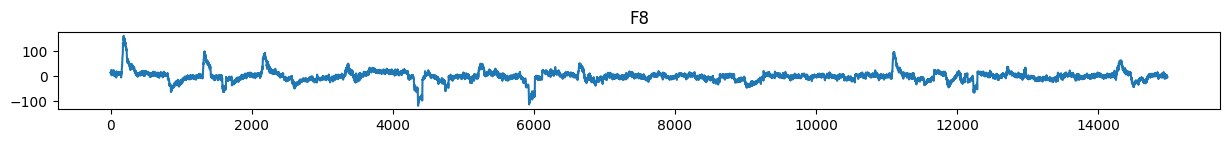

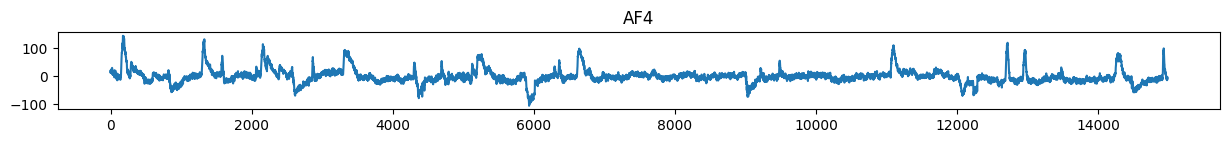

In [640]:
"""X_car.iloc[:, 5].plot(figsize=(15, 1))
plt.show()
df_clean.iloc[:, 5].plot(figsize=(15, 1))
plt.show()"""

for f in X_car.columns:
    X_car[f].plot(figsize=(15, 1), title=f)
    plt.show()

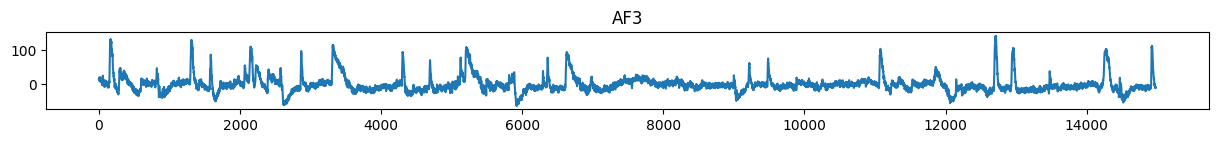

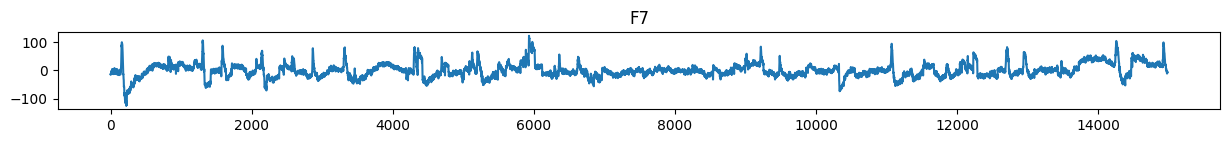

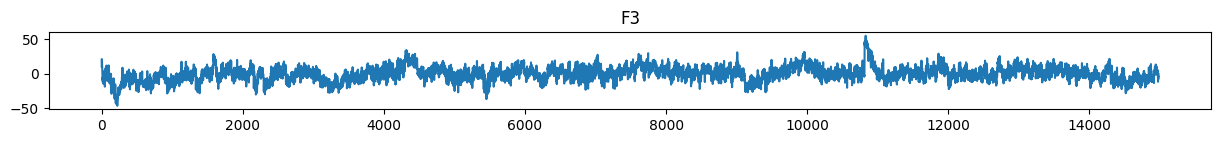

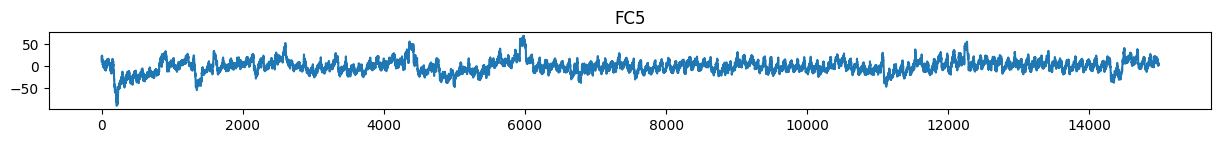

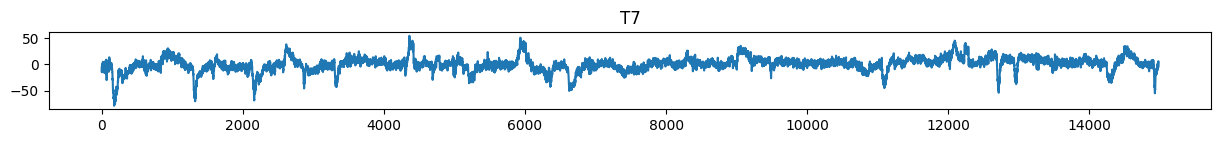

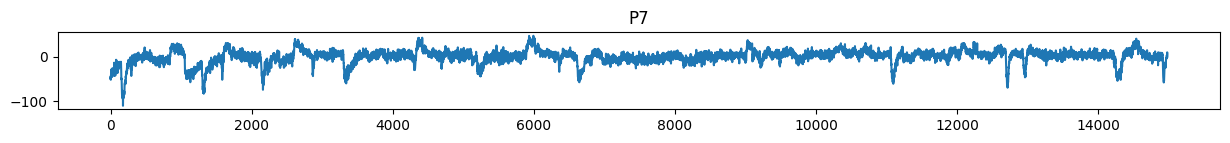

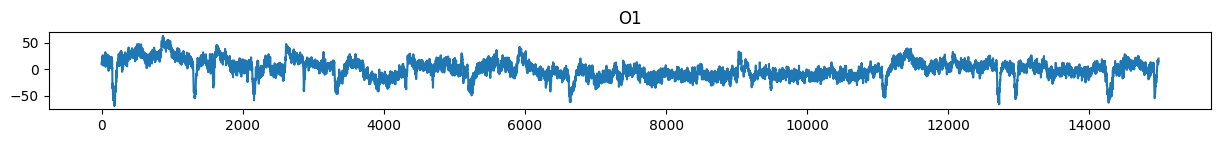

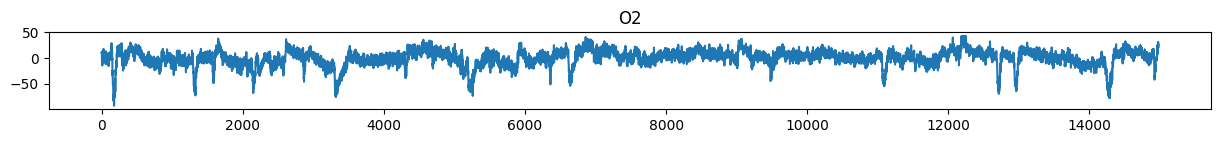

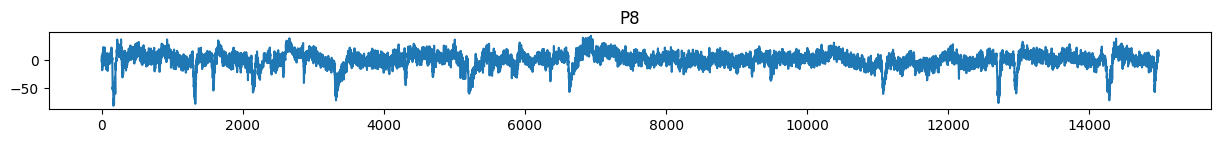

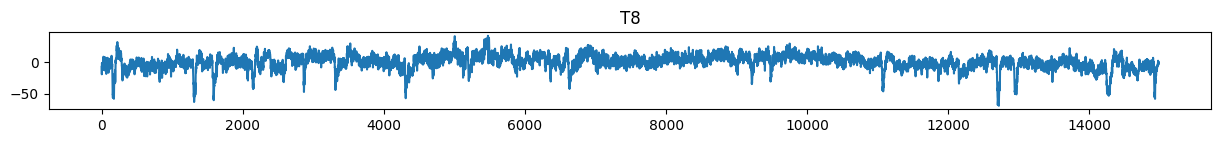

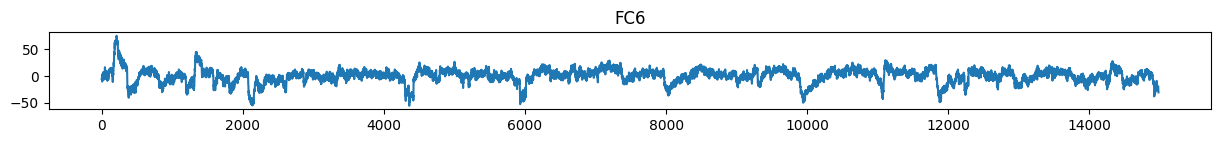

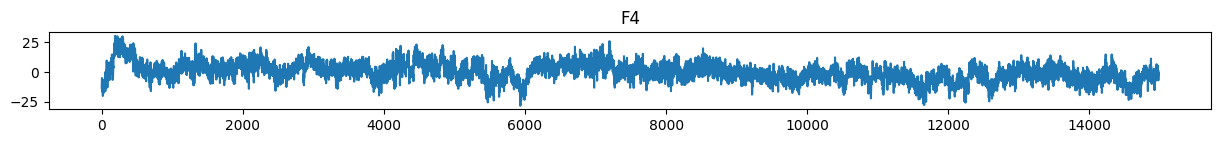

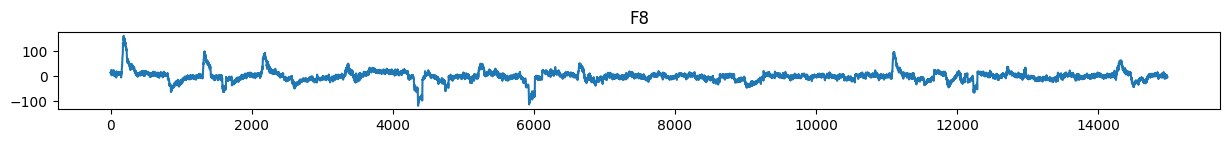

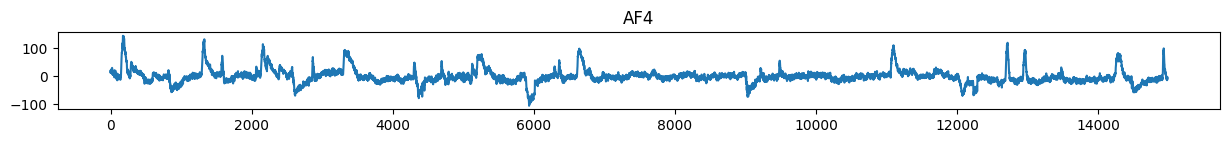

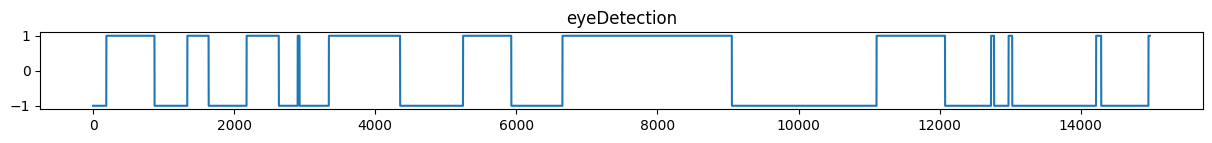

In [641]:
for f in df_clean.columns:
    df_clean[f].plot(figsize=(15, 1), title=f)
    plt.show()

DC power: 1.634575331425664e-23
Mean power: 9181839.206617067


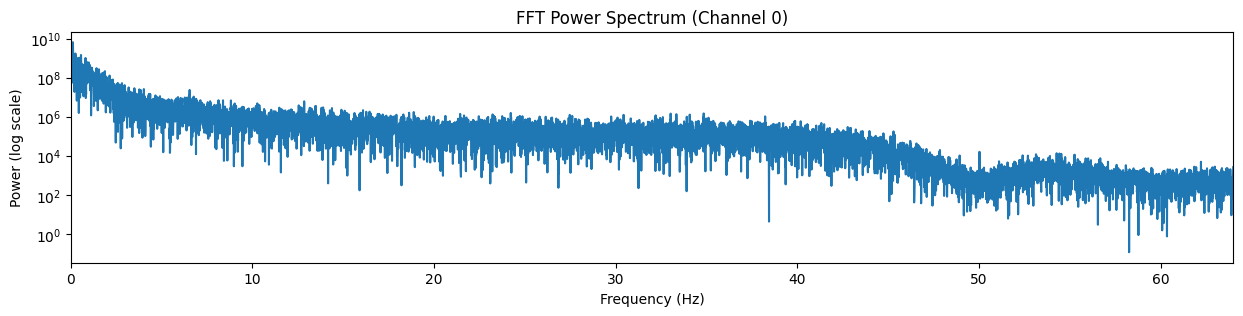

(array([0.00000000e+00, 8.54472630e-03, 1.70894526e-02, ...,
        6.39829105e+01, 6.39914553e+01, 6.40000000e+01], shape=(7491,)),
 array([1.63457533e-23, 3.33393411e+08, 2.62126309e+08, ...,
        5.99144282e+02, 1.84586451e+03, 2.73323574e+03], shape=(7491,)))

In [642]:
def plot_fft_power(df, fs, channel=0, remove_dc=True, plot=True):
    """
    Compute and optionally plot FFT power spectrum for one channel.

    Parameters
    ----------
    df : pd.DataFrame
        EEG data (time x channels)
    fs : int or float
        Sampling frequency
    channel : int
        Channel index
    remove_dc : bool
        Whether to remove DC offset
    plot : bool
        Whether to plot the spectrum

    Returns
    -------
    freqs : np.ndarray
    power : np.ndarray
    """

    # extract signal
    sig = df.iloc[:, channel].to_numpy().astype(float)

    # remove DC offset
    if remove_dc:
        sig = sig - np.mean(sig)

    # FFT
    fft = np.fft.rfft(sig)
    freqs = np.fft.rfftfreq(len(sig), d=1/fs)
    power = np.abs(fft) ** 2

    # debug info
    print("DC power:", power[0])
    print("Mean power:", power.mean())

    # plot
    if plot:
        plt.figure(figsize=(15, 3))
        plt.semilogy(freqs[1:], power[1:])
        plt.xlim(0, fs/2)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power (log scale)")
        plt.title(f"FFT Power Spectrum (Channel {channel})")
        plt.show()

    return freqs, power

fs = 128
plot_fft_power(df_clean, fs)

In [643]:
#Bandwidth for Butterworth filter
fs = 128  # Sampling frequency
lowcut = 0.5  # Low cutoff frequency
highcut = 45.0  # High cutoff frequency 
order = 4  # Filter order

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a
    
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

df_filtered = df_clean.copy()
for f in df.columns[:-1]:  # Exclude the target column
    df_filtered[f] = butter_bandpass_filter(df_clean[f], lowcut, highcut, fs, order)



DC power: 1.197352014606177e-24
Mean power: 724531.3869165665


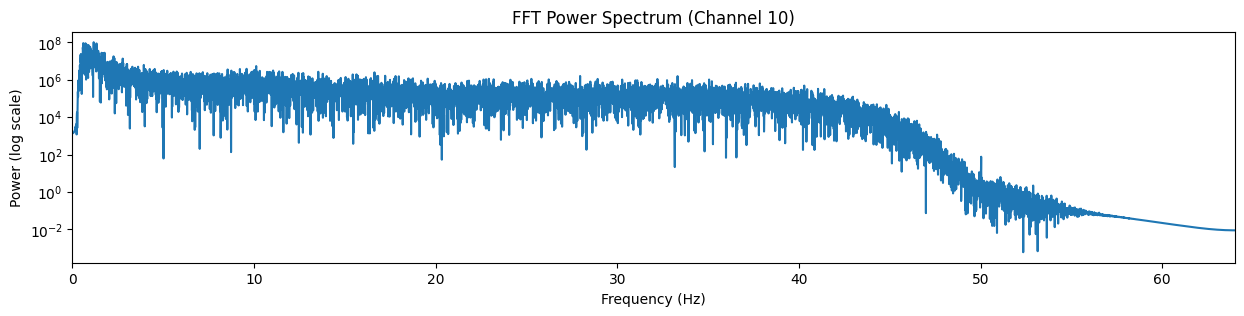

(array([0.00000000e+00, 8.54472630e-03, 1.70894526e-02, ...,
        6.39829105e+01, 6.39914553e+01, 6.40000000e+01], shape=(7491,)),
 array([1.19735201e-24, 1.35914659e+03, 1.36502284e+03, ...,
        8.91728014e-03, 8.91711180e-03, 8.91705569e-03], shape=(7491,)))

In [644]:
plot_fft_power(df_filtered, fs, channel=10)

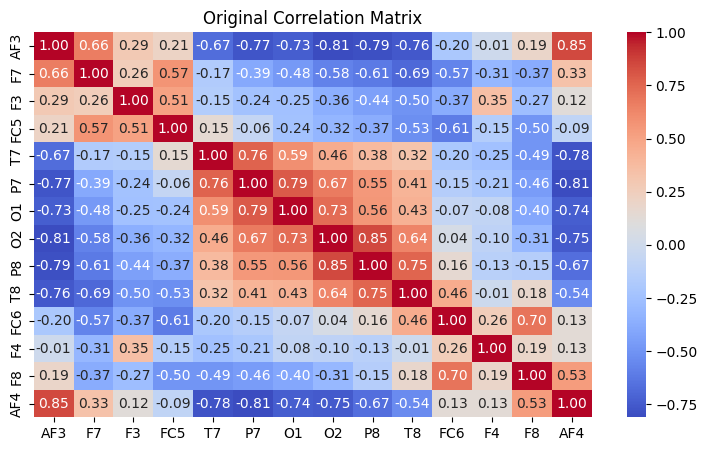

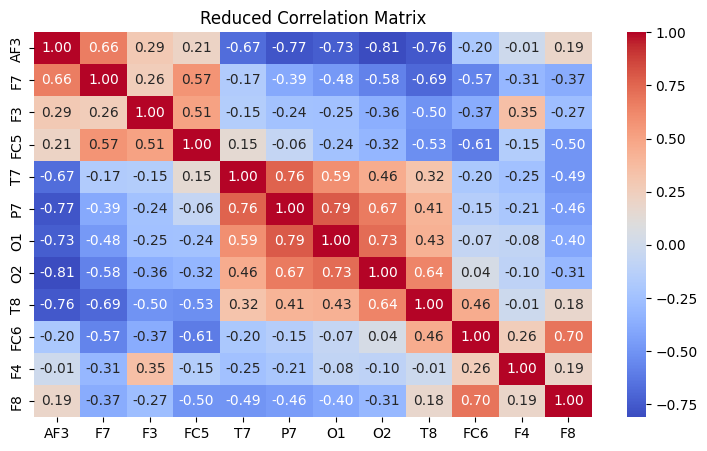

Removed 2 channels: ['P8', 'AF4']
Remaining channels: 12


In [645]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def remove_correlated_channels(df, threshold=0.8, plot=True):
    """
    Remove highly correlated channels and plot correlation matrices.

    Parameters
    ----------
    df : pd.DataFrame
        EEG data (time x channels)
    threshold : float
        Correlation threshold above which channels are removed
    plot : bool
        Whether to show correlation matrices

    Returns
    -------
    df_reduced : pd.DataFrame
        DataFrame with reduced channels
    dropped_cols : list
        List of removed channel names
    """

    # --- 1. Correlation matrix ---
    corr = df.corr()

    if plot:
        plt.figure(figsize=(9, 5))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("Original Correlation Matrix")
        plt.show()

    # --- 2. Find correlated pairs ---
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    # --- 3. Drop columns ---
    df_reduced = df.drop(columns=to_drop)

    # --- 4. New correlation matrix ---
    corr_new = df_reduced.corr()

    if plot:
        plt.figure(figsize=(9, 5))
        sns.heatmap(corr_new, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("Reduced Correlation Matrix")
        plt.show()

    print(f"Removed {len(to_drop)} channels: {to_drop}")
    print(f"Remaining channels: {df_reduced.shape[1]}")

    return df_reduced, to_drop

df_reduced, dropped_channels = remove_correlated_channels(df_filtered.iloc[:, :-1], threshold=0.8, plot=True)

In [646]:
eeg_data = df_reduced.iloc[:, :-1]

epoch_len = int(1 * fs)
step = epoch_len // 2

X_list = []
y_list = []

labels = df_filtered.iloc[:, -1].to_numpy()

for start in range(0, len(eeg_data) - epoch_len, step):
    end = start + epoch_len
    epoch_labels = labels[start:end]

    if np.all(epoch_labels == epoch_labels[0]):
        X_list.append(eeg_data.iloc[start:end].to_numpy())
        y_list.append(epoch_labels[0])

X = np.stack(X_list)  # shape: (n_epochs, epoch_len, n_channels)
y = np.array(y_list)  # shape: (n_epochs,)

print("Epochs shape:", X.shape)
print("Eye open:", np.sum(y==-1), "Eye closed:", np.sum(y==1))

Epochs shape: (195, 128, 11)
Eye open: 105 Eye closed: 90


In [647]:
df_filtered.shape

(14980, 15)

In [648]:
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_flat = df_filtered.iloc[:, :-1]
y = df_filtered.iloc[:, -1]

#n_samples, n_channels = X.shape
#X_flat = X.reshape(n_epochs, n_samples * n_channels)  # shape: (n_epochs, n_samples*n_channels)

# --- Step 1: train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

# --- Step 2: scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 3: create SVM ---
svm_model = SVC(kernel='rbf', C=100, gamma='auto')

# --- Step 4: train SVM ---
svm_model.fit(X_train_scaled, y_train)

# --- Step 5: predict and evaluate ---
y_pred = svm_model.predict(X_test_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.6692

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.69      0.72      0.70      1651
         1.0       0.64      0.61      0.62      1345

    accuracy                           0.67      2996
   macro avg       0.67      0.66      0.66      2996
weighted avg       0.67      0.67      0.67      2996

Confusion Matrix:
[[1182  469]
 [ 522  823]]


In [649]:
from scipy.signal import welch

def compute_bandpowers(X, fs, bands):
    """
    X: (n_epochs, n_samples, n_channels)
    returns: (n_epochs, n_channels, n_bands)
    """

    n_epochs, n_samples, n_channels = X.shape
    band_names = list(bands.keys())
    n_bands = len(bands)

    bandpowers = np.zeros([n_epochs, n_channels, n_bands])

    for e in range(n_epochs):
        for ch in range(n_channels):
            sig = X[e, :, ch]

            freqs, psd = welch(sig, fs=fs, nperseg=min(n_samples, fs*2))

            for b_idx, (band, (fmin, fmax)) in enumerate(bands.items()):
                idx = (freqs >= fmin) & (freqs <= fmax)
                bandpowers[e, ch, b_idx] = np.trapezoid(psd[idx], freqs[idx])

    return bandpowers, band_names

In [650]:
def build_feature_matrix(bandpowers, band_names):
    """
    bandpowers: (n_epochs, n_channels, n_bands)
    band_names: list of band names (e.g. ["delta","theta","alpha","beta"])

    returns:
        X_feat: (n_epochs, n_features)
    """

    n_epochs, n_channels, n_bands = bandpowers.shape

    # --- Find indices for alpha and beta ---
    try:
        alpha_idx = band_names.index("alpha")
        beta_idx = band_names.index("beta")
    except ValueError:
        raise ValueError("Bands must include 'alpha' and 'beta'")

    # --- 1. Flatten bandpowers ---
    bp_flat = bandpowers.reshape(n_epochs, -1)

    # --- 2. Alpha/Beta ratio per channel ---
    alpha_power = bandpowers[:, :, alpha_idx]
    beta_power = bandpowers[:, :, beta_idx]

    # Avoid division by zero
    ratio = alpha_power / (beta_power + 1e-8)  # shape: (n_epochs, n_channels)

    # --- 3. Mean per channel ---
    mean_per_channel = bandpowers.mean(axis=1)  # shape: (n_epochs, n_bands)

    # --- 4. Concatenate everything ---
    X_feat = np.concatenate([
        bp_flat,
        #ratio,
        mean_per_channel
    ], axis=1)

    return X_feat

In [651]:
# Define sampling frequency and EEG frequency bands
fs = int(fs)
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    #"alpha2": (10, 12),
    "beta": (12, 30),
    #"beta2": (20, 30),
    #"gamma": (30, 45)
}

In [652]:
# Compute band powers and create features
bandpowers, band_names = compute_bandpowers(X, fs, bands)
bp_log = np.log(bandpowers + 1e-8) # log-transform bandpowers
#X_feat = bandpower_to_features(bandpowers, log_transform=True)
X_feat = build_feature_matrix(bp_log, list(bands.keys()))
#X_feat = np.concatenate([X_feat, X_feat_ratio], axis=1)
print(X_feat.shape)
print(y.shape)

(195, 48)
(14980,)


ValueError: 'c' argument has 14980 elements, which is inconsistent with 'x' and 'y' with size 195.

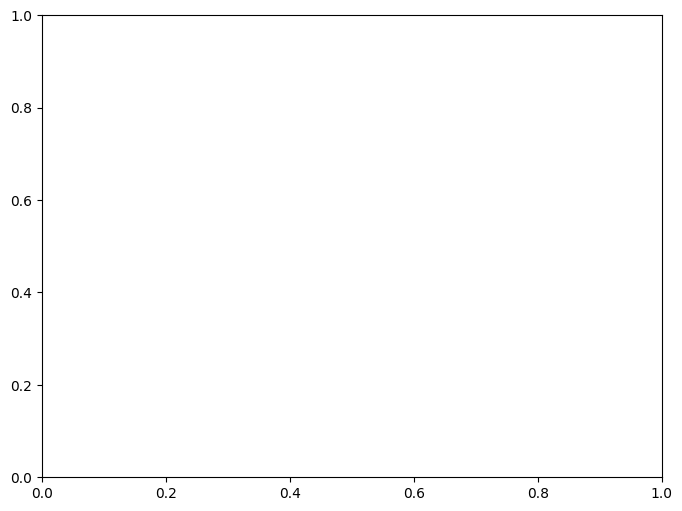

In [653]:
# --- Step 1: find indices for alpha and beta bands ---
alpha_idx = band_names.index('alpha')
beta_idx = band_names.index('beta')

# --- Step 2: average bandpowers across channels (per epoch) ---
alpha_power = bandpowers[:, :, alpha_idx].mean(axis=1)  # shape: (n_epochs,)
beta_power  = bandpowers[:, :, beta_idx].mean(axis=1)

# --- Step 3: create scatter plot colored by class ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    alpha_power,
    beta_power,
    c=y,               # use class labels for color
    cmap='viridis',    # colormap
    alpha=0.7,
    edgecolors='k'
)

# --- Step 4: add colorbar and labels ---
plt.xlabel('Alpha Power (avg across channels)')
plt.ylabel('Beta Power (avg across channels)')
plt.title('Alpha vs Beta Bandpowers by Class')
plt.grid(True)

# Add colorbar with class labels
cbar = plt.colorbar(scatter)
cbar.set_label('Class')

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y,
    test_size=0.2,
    random_state=12,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': [3,5,7,9,11]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

# --- Step 1: create the model ---
knn = KNeighborsClassifier(
    n_neighbors=7,       # k = 5 (you can tune this)
    weights='distance',   # or 'distance' to weight closer neighbors more
    metric='minkowski',  # standard Euclidean distance
    p=3                  # p=2 → Euclidean
)

# --- Step 2: train the model ---
knn.fit(X_train_scaled, y_train)

# --- Step 3: make predictions ---
y_pred = knn.predict(X_test_scaled)

# --- Step 4: evaluate ---
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

{'n_neighbors': 7}
Test Accuracy: 0.5897

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.62      0.62      0.62        21
         1.0       0.56      0.56      0.56        18

    accuracy                           0.59        39
   macro avg       0.59      0.59      0.59        39
weighted avg       0.59      0.59      0.59        39

Confusion Matrix:
[[13  8]
 [ 8 10]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

# --- Step 1: create the model ---
logreg = LogisticRegression(
    penalty='l2',        # L2 regularization (ridge)
    C=0.1,               # regularization strength (1.0 default)
    solver='lbfgs',      # robust solver for small/medium datasets
    max_iter=1000,       # ensure convergence
)

# --- Step 2: train the model ---
logreg.fit(X_train_scaled, y_train)

# --- Step 3: make predictions ---
y_pred = logreg.predict(X_test_scaled)

# --- Step 4: evaluate ---
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

{'C': 0.1}
Test Accuracy: 0.6154

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.64      0.67      0.65        21
         1.0       0.59      0.56      0.57        18

    accuracy                           0.62        39
   macro avg       0.61      0.61      0.61        39
weighted avg       0.61      0.62      0.61        39

Confusion Matrix:
[[14  7]
 [ 8 10]]


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# --- Step 0: define parameter grid for GridSearch ---
param_grid = {
    'C': [0.1, 1, 10, 100],        # regularization strength
    'gamma': ['scale', 0.01, 0.1, 1],  # RBF kernel coefficient
    'kernel': ['rbf']               # kernel type
}

# --- Step 1: GridSearchCV to find best hyperparameters ---
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best parameters found:", grid.best_params_)

# --- Step 2: create the model using best parameters ---
best_params = grid.best_params_
svm_model = SVC(
    C=best_params['C'],
    gamma=best_params['gamma'],
    kernel=best_params['kernel']
)

# --- Step 3: train the model ---
svm_model.fit(X_train_scaled, y_train)

# --- Step 4: make predictions ---
y_pred = svm_model.predict(X_test_scaled)

# --- Step 5: evaluate ---
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best parameters found: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Test Accuracy: 0.5128

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.58      0.33      0.42        21
         1.0       0.48      0.72      0.58        18

    accuracy                           0.51        39
   macro avg       0.53      0.53      0.50        39
weighted avg       0.54      0.51      0.50        39

Confusion Matrix:
[[ 7 14]
 [ 5 13]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import numpy as np

# --- Step 0: define parameter grid for GridSearch ---
param_grid = {
    'n_estimators': [50, 100, 200],  # number of trees
    'max_depth': [None, 5, 10, 20],  # maximum tree depth
    'min_samples_split': [2, 5, 10], # minimum samples to split a node
}

# --- Step 1: GridSearchCV to find best hyperparameters ---
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best parameters found:", grid.best_params_)

# --- Step 2: create the model using best parameters ---
best_params = grid.best_params_
rf_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=42
)

# --- Step 3: train the model ---
rf_model.fit(X_train_scaled, y_train)

# --- Step 4: make predictions ---
y_pred = rf_model.predict(X_test_scaled)

# --- Step 5: evaluate ---
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best parameters found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}

Test Accuracy: 0.5641

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.58      0.67      0.62        21
         1.0       0.53      0.44      0.48        18

    accuracy                           0.56        39
   macro avg       0.56      0.56      0.55        39
weighted avg       0.56      0.56      0.56        39

Confusion Matrix:
[[14  7]
 [10  8]]
